# Projeto Titanic — Previsão de Sobrevivência
# Titanic Project — Survival Prediction

Modelo de classificação para prever a sobrevivência dos passageiros do Titanic.

Classification model to predict Titanic passenger survival.

> **Variável-alvo / Target variable:** `Survived` — `1` representa sobrevivência / represents survival, e `0` representa não sobrevivência / represents non-survival.

## Guia do notebook / Notebook guide

**PT:** Este notebook segue um fluxo completo de Machine Learning: carregamento dos dados, análise inicial, limpeza, codificação de variáveis categóricas, engenharia de atributos, treinamento, avaliação e geração do arquivo de previsão. Cada seção Markdown explica o objetivo da etapa antes do código correspondente.

**EN:** This notebook follows a complete Machine Learning workflow: data loading, initial analysis, cleaning, categorical-feature encoding, feature engineering, training, evaluation, and prediction-file generation. Each Markdown section explains the goal of the step before its corresponding code.

### Sequência de etapas / Workflow sequence

1. Inspeção e qualidade dos dados / Data inspection and quality
2. Limpeza, valores ausentes e codificação / Cleaning, missing values, and encoding
3. Treinamento e avaliação inicial / Initial training and evaluation
4. Escalonamento e engenharia de atributos / Scaling and feature engineering
5. Seleção de atributos, modelo final e exportação / Feature selection, final model, and export

In [1]:
# importando bibliotecas utilizadas
# importing used libraries
import pandas as pd
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# lendo os dados
# reading the data
treino = pd.read_csv("DATA/train.csv")
test = pd.read_csv("DATA/test.csv")

## 1. Inspeção inicial das bases / Initial dataset inspection

`train.csv` contém `Survived`; `test.csv` será usado para as previsões finais.

`train.csv` contains `Survived`; `test.csv` will be used for final predictions.

Visualizando a base de treino e teste.

Visualizing the training and test sets

In [3]:
treino.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
test.head(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


## 2. Estrutura e qualidade dos dados / Data structure and quality

`info()` mostra tipos de dados e valores não nulos.

`info()` shows data types and non-null values.

Verificando as informações da base.

Verifying database information

In [5]:
treino.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


## 3. Cardinalidade das variáveis / Variable cardinality

Cardinalidade mostra quantos valores distintos há em cada coluna.

Cardinality shows how many distinct values each column has.

Verificando a cardinalidade dos dados.

Checking data cardinality

In [7]:
treino.nunique().sort_values(ascending=False)

PassengerId    891
Name           891
Ticket         681
Fare           248
Cabin          147
Age             88
SibSp            7
Parch            7
Embarked         3
Pclass           3
Survived         2
Sex              2
dtype: int64

In [8]:
test.nunique().sort_values(ascending=False)

PassengerId    418
Name           418
Ticket         363
Fare           169
Age             79
Cabin           76
Parch            8
SibSp            7
Pclass           3
Embarked         3
Sex              2
dtype: int64

## 4. Identificação de valores ausentes / Missing-value identification

Verificamos quais colunas precisam de tratamento de valores ausentes.

We check which columns need missing-value treatment.

Verificando os valores nulos.

checking for null values

In [9]:
treino.isnull().sum().sort_values(ascending=False).head(5)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
dtype: int64

In [10]:
test.isnull().sum().sort_values(ascending=False).head(5)

Cabin     327
Age        86
Fare        1
Name        0
Pclass      0
dtype: int64

Treino: valores ausentes em `Age` e `Embarked`; teste: em `Age` e `Fare`.

Training: missing values in `Age` and `Embarked`; test: in `Age` and `Fare`.

We have columns containing empty values ​​in the test set that are not empty in the training set (in this case, we will need to handle these columns only in the test set).

## 5. Limpeza e preparação dos dados / Data cleaning and preparation

Removemos colunas pouco úteis e tratamos os valores ausentes.

We remove less useful columns and treat missing values.

Fazendo o tratamento de dados para valores nulos e cardinalidades.

Handling null values ​​and cardinalities during data processing

In [11]:
treino = treino.drop(['Name', 'Ticket', 'Cabin'], axis=1)

In [12]:
test = test.drop(['Name', 'Ticket', 'Cabin'],axis=1)

As colunas `Name`, `Ticket` e `Cabin` são removidas nesta versão do projeto porque possuem muitos valores distintos e exigiriam engenharia de atributos adicional.

The `Name`, `Ticket`, and `Cabin` columns are removed in this version of the project because they have many distinct values and would require additional feature engineering.

Para lidar com valores nulos no campo `Age`, é utilizada a média de idade. Essa é uma imputação simples que preserva a quantidade de registros.

To handle missing values in the `Age` field, the mean age is used. This is a simple imputation that preserves the number of records.

To handle null values ​​in the "age" field, the mean age is being used.

In [13]:
treino.Age.mean()

np.float64(29.69911764705882)

In [14]:
treino.loc[treino.Age.isnull(),'Age'] = treino.Age.mean()

In [15]:
test.loc[test.Age.isnull(),'Age'] = test.Age.mean()

Para `Embarked`, uma variável categórica, utiliza-se a moda: a categoria mais frequente. Para `Fare`, uma variável numérica, utiliza-se a média. Após a imputação, a checagem seguinte confirma que não restaram valores nulos.

For `Embarked`, a categorical variable, the mode is used: the most frequent category. For `Fare`, a numerical variable, the mean is used. After imputation, the next check confirms that no null values remain.

Since there are still two columns with null values—"Embarked" and "Fare"—the mode will be used to fill in the missing values.

In [16]:
treino.Embarked.mode()[0]

'S'

In [17]:
treino.loc[treino.Embarked.isnull(),'Embarked'] = treino.Embarked.mode()[0]

In [18]:
test.loc[test.Fare.isnull(),'Fare'] = test.Fare.mean()

Confirmando se ainda existe valores nulos

Verifying if there are still null values.

In [19]:
treino.isnull().sum().sort_values(ascending=False).head(5)

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
dtype: int64

In [20]:
test.isnull().sum().sort_values(ascending=False).head(5)

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
dtype: int64

## 6. Codificação das variáveis categóricas / Categorical-variable encoding

`Sex` é convertida em `MaleCheck`: masculino = `1` e feminino = `0`.

`Sex` is converted into `MaleCheck`: male = `1` and female = `0`.

In [21]:
treino.columns[treino.dtypes == 'str']

Index(['Sex', 'Embarked'], dtype='str')

In [22]:
treino.Sex.value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [23]:
treino.Embarked.value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [24]:
treino['MaleCheck'] = treino.Sex.apply(lambda x: 1 if x == 'male' else 0)

In [25]:
treino.value_counts(['Sex', 'MaleCheck'])

Sex     MaleCheck
male    1            577
female  0            314
Name: count, dtype: int64

In [26]:
test['MaleCheck'] = test.Sex.apply(lambda x: 1 if x == 'male' else 0)

In [27]:
test.value_counts(['Sex', 'MaleCheck'])

Sex     MaleCheck
male    1            266
female  0            152
Name: count, dtype: int64

### Codificação de `Embarked` com One-Hot Encoding / `Embarked` encoding with One-Hot Encoding

`OneHotEncoder` cria uma coluna para cada porto de embarque.

`OneHotEncoder` creates one column for each embarkation port.

Then, the original text columns are removed.

In [28]:
ohe = OneHotEncoder(handle_unknown='ignore', dtype='int32')

In [29]:
ohe = ohe.fit(treino[['Embarked']])

In [30]:
ohe.transform(treino[['Embarked']]).toarray()

array([[0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [1, 0, 0],
       [0, 1, 0]], shape=(891, 3), dtype=int32)

In [31]:
ohe_df = pd.DataFrame(ohe.transform(treino[['Embarked']]).toarray(),columns=ohe.get_feature_names_out())
ohe_df.head(5)

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [32]:
treino = pd.concat([treino,ohe_df],axis=1)

In [33]:
treino[['Embarked','Embarked_C','Embarked_Q','Embarked_S']].value_counts()

Embarked  Embarked_C  Embarked_Q  Embarked_S
S         0           0           1             646
C         1           0           0             168
Q         0           1           0              77
Name: count, dtype: int64

In [34]:

ohe_df = pd.DataFrame(ohe.transform(test[['Embarked']]).toarray(),columns=ohe.get_feature_names_out())

In [35]:
test = pd.concat([test,ohe_df],axis=1)

In [36]:
test[['Embarked','Embarked_C','Embarked_Q','Embarked_S']].value_counts()

Embarked  Embarked_C  Embarked_Q  Embarked_S
S         0           0           1             270
C         1           0           0             102
Q         0           1           0              46
Name: count, dtype: int64

In [37]:
treino.head(3)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,MaleCheck,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,male,22.0,1,0,7.2500,S,1,0,0,1
1,2,1,1,female,38.0,1,0,71.2833,C,0,1,0,0
2,3,1,3,female,26.0,0,0,7.9250,S,0,0,0,1


In [38]:
treino = treino.drop(['Sex','Embarked'],axis=1)

In [39]:
test = test.drop(['Sex','Embarked'],axis=1)

In [40]:
treino.head(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,MaleCheck,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,1,0,0,1
1,2,1,1,38.0,1,0,71.2833,0,1,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,0,1


## 7. Definição dos atributos e separação para validação / Feature definition and validation split

`X` contém os atributos; `Y` contém o alvo `Survived`.

`X` contains the features; `Y` contains the `Survived` target.

33% dos dados são reservados para validação; `random_state=42` torna a divisão reproduzível.

33% of the data is reserved for validation; `random_state=42` makes the split reproducible.

In [41]:
X = treino.drop(['PassengerId', 'Survived'],axis= 1)
Y = treino.Survived

In [42]:
X_treino, X_Val, Y_treino, Y_Val = train_test_split(X, Y, test_size=0.33, random_state=42)

## 8. Treinamento e comparação de modelos / Model training and comparison

Três classificadores são treinados com a mesma base: 

- **Árvore de decisão:** aprende regras condicionais a partir dos atributos.
- **KNN:** classifica cada passageiro pela classe predominante entre seus três vizinhos mais próximos.
- **Regressão logística:** estima a probabilidade de sobrevivência a partir das variáveis disponíveis.

Three classifiers are trained with the same dataset:

- **Decision tree:** learns conditional rules from the features.
- **KNN:** classifies each passenger using the predominant class among its three closest neighbors.
- **Logistic regression:** estimates the probability of survival based on the available features.

Após o ajuste, cada modelo prevê `X_Val`.

After fitting, each model predicts `X_Val`.

In [43]:
clf_ac = tree.DecisionTreeClassifier(random_state=42)

In [44]:
clf_ac = clf_ac.fit(X_treino, Y_treino)

In [45]:
y_pred_ac = clf_ac.predict(X_Val)

In [46]:
print(X_treino.dtypes)

Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
MaleCheck       int64
Embarked_C      int32
Embarked_Q      int32
Embarked_S      int32
dtype: object


In [47]:
clf_knn = KNeighborsClassifier(n_neighbors=3)

In [48]:
clf_knn = clf_knn.fit(X_treino,Y_treino)

In [49]:
y_pred_knn = clf_knn.predict(X_Val)

In [50]:
clf_rl = LogisticRegression(random_state=42, max_iter=1000)

In [51]:
clf_rl = clf_rl.fit(X_treino,Y_treino)

In [52]:
y_pred_rl = clf_rl.predict(X_Val)

## 9. Avaliação dos modelos / Model evaluation

A **acurácia** mede os acertos; a **matriz de confusão** detalha os erros.

**Accuracy** measures correct predictions; the **confusion matrix** details the errors.

Essas métricas ajudam a escolher o classificador final.

These metrics help select the final classifier.

In [53]:
ac_ac =accuracy_score(Y_Val, y_pred_ac)
ac_ac

0.7491525423728813

In [54]:
ac_knn = accuracy_score(Y_Val, y_pred_knn)
ac_knn

0.7152542372881356

In [55]:
ac_rl = accuracy_score(Y_Val, y_pred_rl)
ac_rl

0.8169491525423729

In [56]:
as_df = pd.DataFrame({
    'modelos' : ['arvore', 'Knn', 'reg. log.'],
    'inicial' : [ac_ac, ac_knn, ac_rl]
})

as_df

,modelos,inicial
0,arvore,0.749153
1,Knn,0.715254
2,reg. log.,0.816949


In [57]:
confusion_matrix(Y_Val, y_pred_ac)

array([[138,  37],
       [ 37,  83]])

In [58]:
confusion_matrix(Y_Val, y_pred_knn)

array([[147,  28],
       [ 56,  64]])

In [59]:
confusion_matrix(Y_Val, y_pred_rl)

array([[153,  22],
       [ 32,  88]])

## 10. Escalonamento de variáveis / Feature scaling

**PT:** Nesta etapa, verifico se `Age` e `Fare` estão em escalas muito diferentes. Em seguida, aplico `RobustScaler` para reduzir a influência de valores extremos e permitir uma comparação mais equilibrada entre os atributos. Depois, treino os mesmos modelos novamente para medir o efeito desse ajuste.

**EN:** In this step, I check whether `Age` and `Fare` are on very different scales. Next, I apply `RobustScaler` to reduce the influence of extreme values and enable a more balanced comparison between features. Then, I train the same models again to measure the effect of this adjustment.

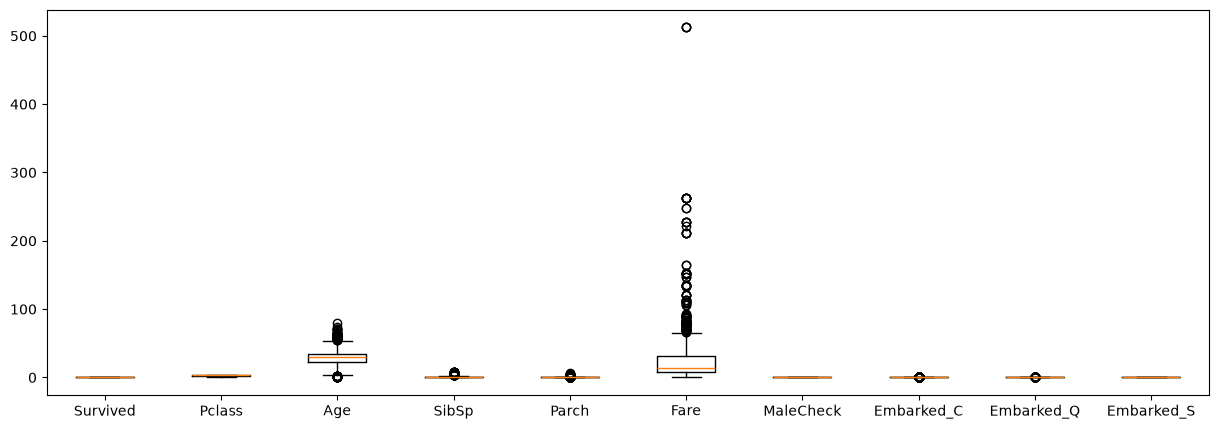

In [60]:
fig, ax = plt.subplots(figsize=(15,5))

ax.boxplot(treino.iloc[:, 1:11])
ax.set_xticks(range(1, treino.iloc[:, 1:11].shape[1]+1),treino.iloc[:, 1:11].columns)

plt.show()

In [61]:
trasformer = RobustScaler().fit(treino[['Age', 'Fare']])

In [62]:
treino[['Age', 'Fare']] = trasformer.transform(treino[['Age', 'Fare']])

In [63]:
trasformer = RobustScaler().fit(test[['Age', 'Fare']])

In [64]:
test[['Age', 'Fare']] = trasformer.transform(test[['Age', 'Fare']])

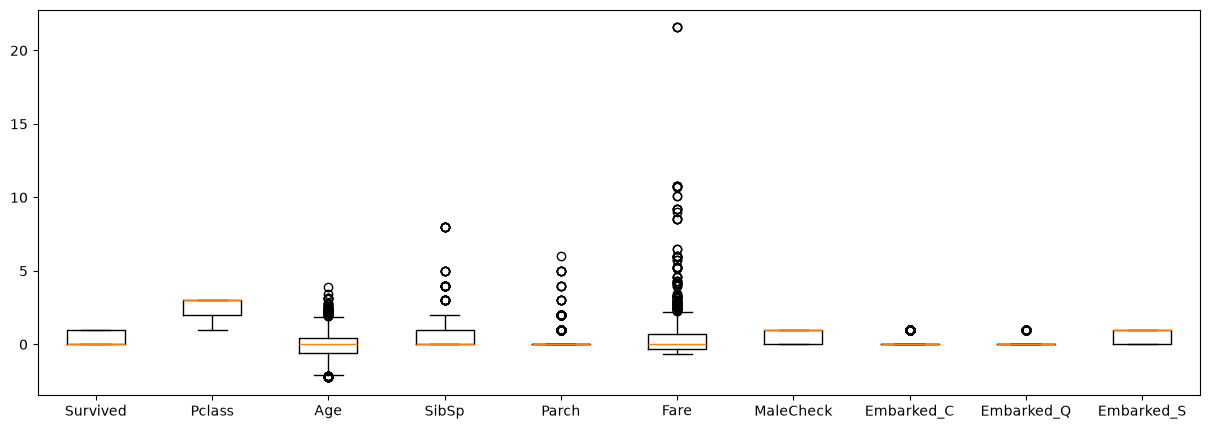

In [65]:
fig, ax = plt.subplots(figsize=(15,5))

ax.boxplot(treino.iloc[:, 1:11])
ax.set_xticks(range(1, treino.iloc[:, 1:11].shape[1]+1),treino.iloc[:, 1:11].columns)

plt.show()

In [66]:
X = treino.drop(['PassengerId', 'Survived'],axis= 1)
Y = treino.Survived

X_treino, X_Val, Y_treino, Y_Val = train_test_split(X, Y, test_size=0.33, random_state=42)

In [67]:
clf_ac = tree.DecisionTreeClassifier(random_state=42)
clf_ac = clf_ac.fit(X_treino, Y_treino)
y_pred_ac = clf_ac.predict(X_Val)

In [68]:
clf_knn = KNeighborsClassifier(n_neighbors=3)
clf_knn = clf_knn.fit(X_treino,Y_treino)
y_pred_knn = clf_knn.predict(X_Val)

In [69]:
clf_rl = LogisticRegression(random_state=42, max_iter=1000)
clf_rl = clf_rl.fit(X_treino,Y_treino)
y_pred_rl = clf_rl.predict(X_Val)

In [70]:
ac_ac =accuracy_score(Y_Val, y_pred_ac)
ac_knn = accuracy_score(Y_Val, y_pred_knn)
ac_rl = accuracy_score(Y_Val, y_pred_rl)

In [71]:
as_df['escala'] = [ac_ac, ac_knn, ac_rl]
as_df

,modelos,inicial,escala
0,arvore,0.749153,0.749153
1,Knn,0.715254,0.800000
2,reg. log.,0.816949,0.816949


In [72]:
confusion_matrix(Y_Val, y_pred_ac)

array([[138,  37],
       [ 37,  83]])

In [73]:
confusion_matrix(Y_Val, y_pred_knn)

array([[152,  23],
       [ 36,  84]])

In [74]:
confusion_matrix(Y_Val, y_pred_rl)

array([[153,  22],
       [ 32,  88]])

## 11. Engenharia de atributos de família / Family feature engineering

**PT:** Analiso `SibSp` e `Parch` para observar a sobrevivência conforme a quantidade de familiares a bordo. Também crio `Sozinho`, que identifica quem viajou sem familiares, e `Familiares`, que representa o total de parentes do passageiro.

**EN:** I analyze `SibSp` and `Parch` to observe survival according to the number of relatives aboard. I also create `Sozinho`, which identifies passengers traveling without relatives, and `Familiares`, which represents the passenger's total number of relatives.

In [75]:
SibSp_df = treino.groupby('SibSp')['Survived'].agg(['sum', 'count', 'mean']).reset_index()
SibSp_df.columns = ['SibSp', 'sobrev', 'total', 'tx_sobrev']
SibSp_df

,SibSp,sobrev,total,tx_sobrev
0,0,210,608,0.345395
1,1,112,209,0.535885
2,2,13,28,0.464286
3,3,4,16,0.250000
4,4,3,18,0.166667
5,5,0,5,0.000000
6,8,0,7,0.000000


In [76]:
Parch_df = treino.groupby('Parch')['Survived'].agg(['sum', 'count', 'mean']).reset_index()
Parch_df.columns = ['Parch', 'sobrev', 'total', 'tx_sobrev']
Parch_df

,Parch,sobrev,total,tx_sobrev
0,0,233,678,0.343658
1,1,65,118,0.550847
2,2,40,80,0.500000
3,3,3,5,0.600000
4,4,0,4,0.000000
5,5,1,5,0.200000
6,6,0,1,0.000000


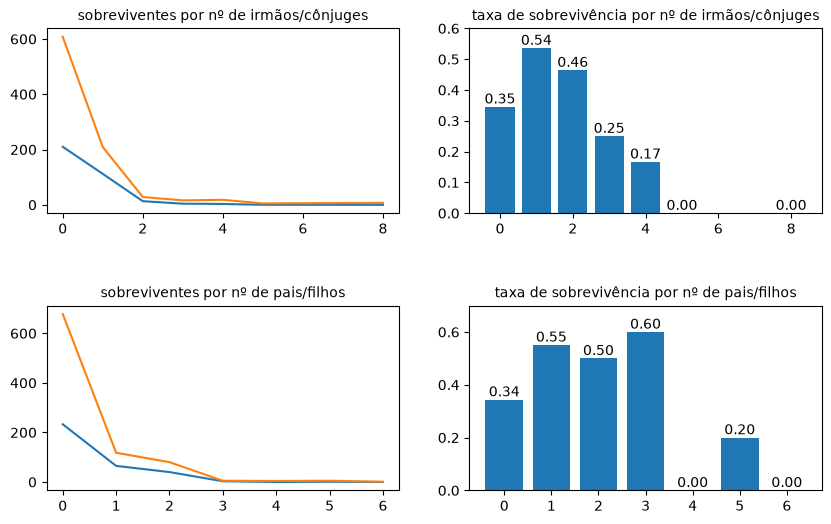

In [77]:
fig, ax = plt.subplots(ncols=2,nrows=2,figsize=(10,6))

ax[0,0].plot(SibSp_df.SibSp, SibSp_df.sobrev)

ax[0,0].plot(SibSp_df.SibSp, SibSp_df.total)

ax[0,0].set_title('sobreviventes por nº de irmãos/cônjuges', fontsize=10)

labels1 = ax[0,1].bar(SibSp_df.SibSp, SibSp_df.tx_sobrev)

ax[0,1].bar_label(labels1,fmt="%.02f")

ax[0,1].set(ylim=(0,0.6))

ax[0,1].set_title('taxa de sobrevivência por nº de irmãos/cônjuges', fontsize=10)

ax[1,0].plot(Parch_df.Parch, Parch_df.sobrev)

ax[1,0].plot(Parch_df.Parch, Parch_df.total)

ax[1,0].set_title('sobreviventes por nº de pais/filhos', fontsize=10)

labels2 = ax[1,1].bar(Parch_df.Parch, Parch_df.tx_sobrev)

ax[1,1].bar_label(labels2,fmt="%.02f")

ax[1,1].set(ylim=(0,0.7))

ax[1,1].set_title('taxa de sobrevivência por nº de pais/filhos', fontsize=10)

plt.subplots_adjust(hspace=0.5)

plt.show()

In [78]:
def sozinho(a,b):

    if (a == 0 and b == 0):

        return 1

    else:

        return 0

treino['Sozinho'] = treino.apply(lambda x: sozinho(x.SibSp,x.Parch),axis=1)

In [79]:
treino.groupby('Sozinho')[['SibSp','Parch']].mean()

,SibSp,Parch
Sozinho,,
0,1.316384,0.960452
1,0.000000,0.000000


In [80]:
test['Sozinho'] = test.apply(lambda x: sozinho(x.SibSp,x.Parch),axis=1)

In [81]:
treino['Familiares'] = treino.SibSp + treino.Parch

test['Familiares'] = treino.SibSp + treino.Parch

In [82]:
Familiares_df = treino.groupby('Familiares')['Survived'].agg(['sum','count','mean']).reset_index()

In [83]:
Familiares_df.columns = ['Familiares','sobrev','total','tx_sobrev']
Familiares_df

,Familiares,sobrev,total,tx_sobrev
0,0,163,537,0.303538
1,1,89,161,0.552795
2,2,59,102,0.578431
3,3,21,29,0.724138
4,4,3,15,0.200000
5,5,3,22,0.136364
6,6,4,12,0.333333
7,7,0,6,0.000000
8,10,0,7,0.000000


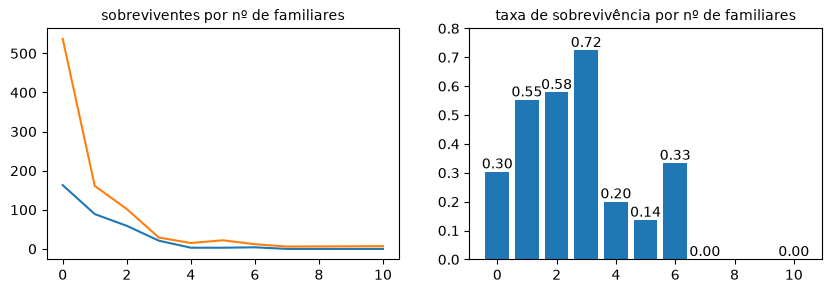

In [84]:
fig, ax = plt.subplots(ncols=2,figsize=(10,3))

ax[0].plot(Familiares_df.Familiares, Familiares_df.sobrev)

ax[0].plot(Familiares_df.Familiares, Familiares_df.total)

ax[0].set_title('sobreviventes por nº de familiares', fontsize=10)

labels1 = ax[1].bar(Familiares_df.Familiares, Familiares_df.tx_sobrev)

ax[1].bar_label(labels1,fmt="%.02f")

ax[1].set(ylim=(0,0.8))

ax[1].set_title('taxa de sobrevivência por nº de familiares', fontsize=10)

plt.show()

In [85]:
treino.head(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,MaleCheck,Embarked_C,Embarked_Q,Embarked_S,Sozinho,Familiares
0,1,0,3,-0.592240,1,0,-0.312011,1,0,0,1,0,1
1,2,1,1,0.638529,1,0,2.461242,0,1,0,0,0,1
2,3,1,3,-0.284548,0,0,-0.282777,0,0,0,1,1,0


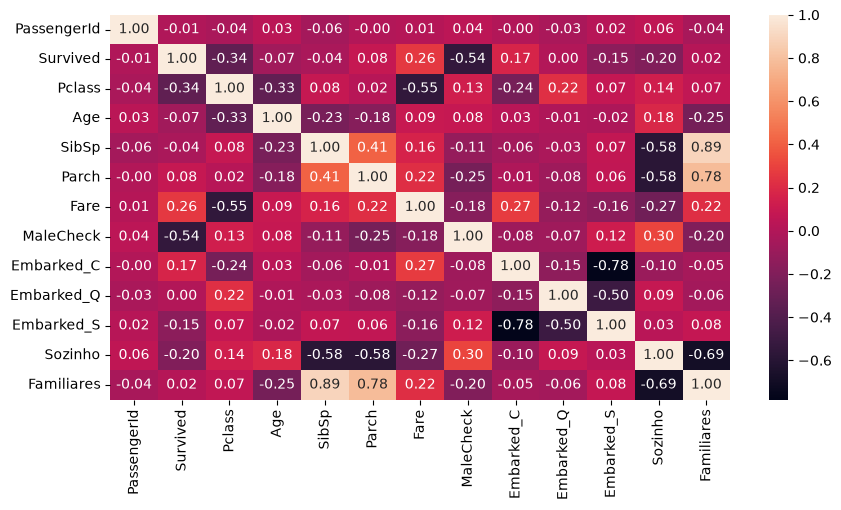

In [86]:
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(treino.corr(), annot=True, fmt=".2f")
plt.show()

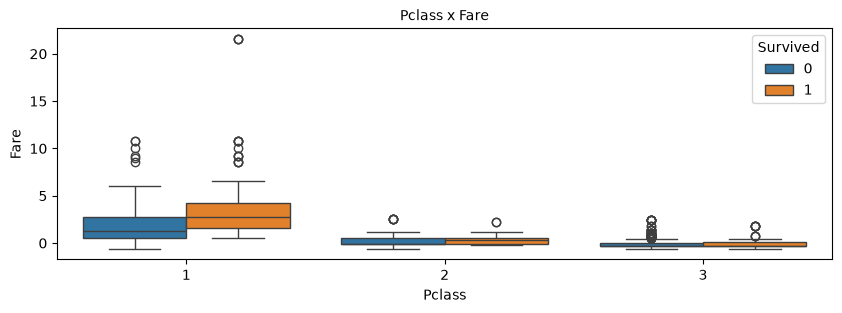

In [87]:
fig, ax = plt.subplots(figsize=(10,3))

sns.boxplot(data=treino,x='Pclass',y='Fare',hue='Survived')

ax.set_title('Pclass x Fare', fontsize=10)

plt.show()

In [88]:
treino.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [89]:
treino.groupby(['Pclass','Survived'])['Fare'].agg(['min','mean','max'])

min      mean        max
Pclass Survived                               
1      0        -0.626005  2.175430  10.764405
       1         0.496977  3.514735  21.562738
2      0        -0.626005  0.214734   2.557247
       1        -0.171255  0.329217   2.189115
3      0        -0.626005 -0.033991   2.386174
       1        -0.626005 -0.032885   1.820802

**PT:**Nesse momento pode surgir a pergunta do motivo de termos pessoas pagando o mesmo preço em classes diferentes.
Procurando no Kaggle(https://www.kaggle.com/discussions/questions-and-answers/128215) ele explica essa resposta:

"Se você conseguiu economizar e guardar todo o seu dinheiro para uma viagem para mudar sua vida e ir para a América, você é uma terceira classe, um imigrante que precisa trazer sua própria comida a bordo e ter em mente como suas provisões se sustentariam. A segunda classe era formada por trabalhadores de colarinho branco que podiam se dar ao luxo de viajar com um pouco de lazer, sem se preocupar com algo tão comum como comida. Primeira classe significa que você nasceu com dinheiro e não precisa sujar as mãos com o trabalho. Eles não eram separados apenas pelo custo, eles também eram separados por onde poderiam ir e o que recebiam.”

Também tem um link do Reddit que detalha bem essa questão de classe x preço
 https://www.reddit.com/r/AskHistorians/comments/11dlsn6/why_was_the_cost_of_tickets_on_the_titanic_so/?tl=pt-br&utm_source=embedv2&utm_medium=post_embed&utm_content=post_title&embed_host_url=https%3A%2F%2Fwww.hashtagtreinamentos.com%2Fanalise-do-titanic-ciencias-de-dados

**EN:**
At this point, you might wonder why some passengers paid the same fare despite traveling in different classes.

After looking into this on Kaggle (https://www.kaggle.com/discussions/questions-and-answers/128215), I found the following explanation:

"If you managed to save up all your money for a trip to change your life and move to America, you were a third-class passenger—an immigrant who had to bring your own food onboard and carefully consider how long your supplies would last. Second class consisted of white-collar workers who could afford to travel with a bit more comfort, without worrying about something as basic as food. First class meant you were born into wealth and did not have to work with your hands. The classes were not separated only by ticket price; they were also distinguished by where passengers could go on the ship and the services they received."

There is also a Reddit discussion that provides a detailed explanation of the relationship between passenger class and ticket price.
 https://www.reddit.com/r/AskHistorians/comments/11dlsn6/why_was_the_cost_of_tickets_on_the_titanic_so/?tl=pt-br&utm_source=embedv2&utm_medium=post_embed&utm_content=post_title&embed_host_url=https%3A%2F%2Fwww.hashtagtreinamentos.com%2Fanalise-do-titanic-ciencias-de-dados

**PT:** Inicialmente pensei que não existia relação de ordem entre a coluna de embarque mas pesquisando, https://pt.wikipedia.org/wiki/RMS_Titanic, percebemos que existe, sim, essa correlação.

“O Titanic deixou o porto de Southampton…Em seguida ele foi para Cherbourg-Octeville na França…em sua maioria da primeira classe. O Titanic então rumou para Queenstown na Irlanda…principalmente imigrantes da terceira classe que pretendiam tentar a vida nos Estados Unidos.”


**EN:** Initially, I assumed that there was no ordinal relationship between the embarkation ports. However, after researching the topic on the RMS Titanic Wikipedia page (https://en.wikipedia.org/wiki/RMS_Titanic), it became clear that such a relationship does exist.

"The Titanic departed from the port of Southampton... It then sailed to Cherbourg, France, where it boarded mostly first-class passengers. The ship's final stop before crossing the Atlantic was Queenstown, Ireland, where it embarked mainly third-class immigrants who hoped to start a new life in the United States."

This suggests that the embarkation port is indirectly associated with passenger class, as different ports tended to board passengers from different socioeconomic backgrounds.

## 12. Relações entre atributos / Feature relationships

**PT:** Uso correlação e gráficos para investigar relações entre as variáveis. O foco é verificar se `Pclass` e `Fare` carregam informações parecidas e como essas variáveis se relacionam com a sobrevivência.

**EN:** I use correlations and charts to investigate relationships between variables. The focus is to check whether `Pclass` and `Fare` carry similar information and how these variables relate to survival.

In [90]:
treino2 = pd.read_csv("DATA/train.csv")
test2 = pd.read_csv("DATA/test.csv")

In [91]:
treino2['Embarked'] = treino2['Embarked'].fillna('S')

In [92]:
categorias = ['S','C','Q']

enc = OrdinalEncoder(categories=[categorias],dtype='int32')

In [93]:
enc = enc.fit(treino2[['Embarked']])

In [94]:
treino['Embarked'] = enc.transform(treino2[['Embarked']])

In [95]:
test['Embarked'] = enc.transform(test2[['Embarked']])

In [96]:
treino = treino.drop(['Embarked_C','Embarked_Q','Embarked_S'],axis=1)
test = test.drop(['Embarked_C','Embarked_Q','Embarked_S'],axis=1)

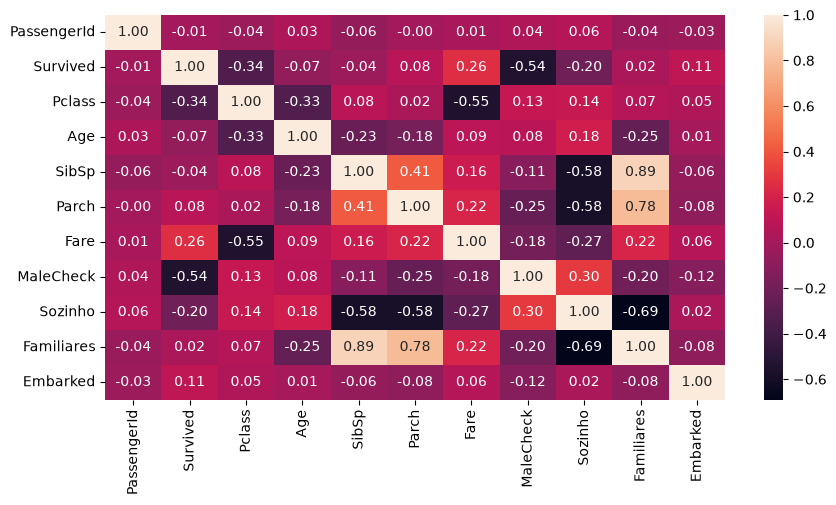

In [97]:
fig, ax = plt.subplots(figsize=(10,5))

sns.heatmap(treino.corr(), annot=True, fmt=".2f")

plt.show()

## 13. Porto de embarque e codificação ordinal / Embarkation port and ordinal encoding

**PT:** Recarrego a coluna `Embarked` em formato textual, trato os valores ausentes e a converto para uma variável ordinal na ordem `S`, `C` e `Q`. Depois, removo as colunas do one-hot encoding para que não existam representações duplicadas do mesmo atributo.

**EN:** I reload the `Embarked` column in text format, handle missing values, and convert it into an ordinal variable using the `S`, `C`, and `Q` order. Then, I remove the one-hot encoded columns so that the same feature is not represented twice.

In [98]:
X = treino.drop(['PassengerId','Survived'],axis=1)
y = treino.Survived

In [99]:
clf_rl = LogisticRegression(random_state=42,max_iter=1000).fit(X,y)

In [100]:
clf_rl.coef_[0]

array([-1.03263042, -0.49652852, -0.26762379,  0.0163412 ,  0.04436238,
       -2.53517931, -0.73082523, -0.25128259,  0.23859331])

In [101]:
clf_ac = tree.DecisionTreeClassifier(random_state=42).fit(X,y)

In [102]:
clf_ac.feature_importances_

array([0.10901775, 0.22826711, 0.01907221, 0.0272942 , 0.23870173,
       0.30933519, 0.00397775, 0.04365035, 0.02068372])

In [103]:
imp = pd.DataFrame({
    'colunas': X.columns,
    'reg. log.': clf_rl.coef_[0],
    'arvore': clf_ac.feature_importances_
})

imp

,colunas,reg. log.,arvore
0,Pclass,-1.032630,0.109018
1,Age,-0.496529,0.228267
2,SibSp,-0.267624,0.019072
3,Parch,0.016341,0.027294
4,Fare,0.044362,0.238702
5,MaleCheck,-2.535179,0.309335
6,Sozinho,-0.730825,0.003978
7,Familiares,-0.251283,0.043650
8,Embarked,0.238593,0.020684


## 14. Importância e seleção de atributos / Feature importance and selection

**PT:** Ajusto uma regressão logística e uma árvore de decisão com toda a base de treino para comparar coeficientes e importâncias. Como `Familiares` resume `SibSp` e `Parch`, removo essas duas colunas originais antes do treinamento final.

**EN:** I fit logistic regression and a decision tree on the full training dataset to compare coefficients and feature importances. Because `Familiares` summarizes `SibSp` and `Parch`, I remove these two original columns before final training.

In [104]:
treino = treino.drop(['SibSp','Parch'],axis=1)
test = test.drop(['SibSp','Parch'],axis=1)

In [105]:
treino.head(3)

,PassengerId,Survived,Pclass,Age,Fare,MaleCheck,Sozinho,Familiares,Embarked
0,1,0,3,-0.592240,-0.312011,1,0,1,0
1,2,1,1,0.638529,2.461242,0,0,1,1
2,3,1,3,-0.284548,-0.282777,0,1,0,0


In [106]:
X = treino.drop(['PassengerId','Survived'],axis=1)
y = treino.Survived

## 15. Treinamento final, validação e exportação / Final training, validation, and export

**PT:** Com os atributos finais, separo treino e validação novamente, treino árvore de decisão, KNN e regressão logística e comparo acurácia e matriz de confusão. Por fim, uso o melhor modelo para prever a base de teste e gerar o arquivo CSV de submissão.

**EN:** With the final features, I split training and validation data again, train decision tree, KNN, and logistic regression models, and compare accuracy and confusion matrices. Finally, I use the best model to predict the test dataset and generate the CSV submission file.

In [107]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=42)

In [108]:
clf_ac = tree.DecisionTreeClassifier(random_state=42)

In [109]:
clf_ac = clf_ac.fit(X_train,y_train)

In [110]:
y_pred_ac = clf_ac.predict(X_val)

In [111]:
clf_knn = KNeighborsClassifier(n_neighbors=3)

In [112]:
clf_knn = clf_knn.fit(X_train,y_train)

In [113]:
y_pred_knn = clf_knn.predict(X_val)

In [114]:
clf_rl = LogisticRegression(random_state=42,max_iter=1000)

In [115]:
clf_rl = clf_rl.fit(X_train,y_train)

In [116]:
y_pred_rl = clf_rl.predict(X_val)

In [117]:
as_ac = accuracy_score(y_val, y_pred_ac)
as_ac

0.7627118644067796

In [118]:
as_knn = accuracy_score(y_val, y_pred_knn)
as_knn

0.7864406779661017

In [119]:
as_rl = accuracy_score(y_val, y_pred_rl)
as_rl

0.8101694915254237

In [120]:
as_df['colunas'] = [as_ac,as_knn,as_rl]
as_df

,modelos,inicial,escala,colunas
0,arvore,0.749153,0.749153,0.762712
1,Knn,0.715254,0.800000,0.786441
2,reg. log.,0.816949,0.816949,0.810169


In [121]:
confusion_matrix(y_val, y_pred_ac)

array([[142,  33],
       [ 37,  83]])

In [122]:
confusion_matrix(y_val, y_pred_knn)

array([[149,  26],
       [ 37,  83]])

In [123]:
confusion_matrix(y_val, y_pred_rl)

array([[154,  21],
       [ 35,  85]])

In [124]:
X_train.head(3)

,Pclass,Age,Fare,MaleCheck,Sozinho,Familiares,Embarked
6,1,1.869299,1.620136,1,1,0,0
718,3,0.000000,0.045293,1,1,0,2
685,2,-0.361471,1.174771,1,0,3,1


In [125]:
test.head(3)

,PassengerId,Pclass,Age,Fare,MaleCheck,Sozinho,Familiares,Embarked
0,892,3,0.331562,-0.280670,1,1,1,2
1,893,3,1.311954,-0.315800,0,0,1,0
2,894,2,2.488424,-0.201943,1,1,0,2


## 16. Geração das previsões finais / Final prediction generation

A base de teste recebe as previsões de `clf_rl`.

The test set receives predictions from `clf_rl`.

`index=False` não inclui o índice do pandas no CSV.

`index=False` keeps the pandas index out of the CSV.

In [ ]:
x_teste = test.drop("PassengerId", axis=1)

y_pred = clf_rl.predict(x_teste)

test["Survived"] = y_pred

base_envio = test[["PassengerId", "Survived"]]
base_envio.to_csv("resultados3.csv", index=False)